In [1]:
import psi4
import numpy as np
import matplotlib.pyplot as plt

# Define the methods/levels of theory
methods = [
    'ccsd', 
    'wb97x-d', 
    'ccsd(t)', 
    'fci'
]
#methods = [
#    "ccsd", 
#    "ccsd(t)"
#]
basis = 'aug-cc-pvdz'

# Initialize a dictionary to store lists of energies for each method
energy_data = {m: [] for m in methods}
distances = []

d_vals = np.linspace(2.0, 8.0, 50) # Example range

for d in d_vals:
    # Update geometry for the current distance
    geom_string = f"""
    0 1
    H  -0.370000000  0.000000000  0.000000000
    H   0.370000000  0.000000000  0.000000000
    H  -0.370000000  0.000000000  {d}
    H   0.370000000  0.000000000  {d}
    unit angstrom
    symmetry c1
    """
    mol = psi4.geometry(geom_string)
    distances.append(d)
    
    for m in methods:
        print(f"Running {m}/{basis} at d = {d:.3f}")
        # Calculation call
        e = psi4.energy(f"{m}/{basis}")
        energy_data[m].append(e)

# 3. Define the Asymptote
# We use the last element index [-1] of the FCI list
fci_asymptote = energy_data['fci'][-1]

Running ccsd/aug-cc-pvdz at d = 2.000

Scratch directory: /tmp/
   => Libint2 <=

    Primary   basis highest AM E, G, H:  6, 6, 3
    Auxiliary basis highest AM E, G, H:  7, 7, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on CHEM9QDFT72ALT
*** at Mon Apr  6 13:04:34 2026

   => Loading Basis Set <=

    Name: AUG-CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-4 entry H          line    40 file /Users/jfoley19/miniconda3/envs/psi4_new/share/psi4/basis/aug-cc-pvdz.gbs 


         ---------------------------------------------------------
                                   SCF
               by Justin Turney, Rob Parrish, Andy Simmonett
                          and Daniel G. A. Smith
                              RHF Reference
                        1 Threads,    500 MiB Core
         ---------------------------------------------------------

  ==> Geometry <==

    Molecular point group: c1
    Full 

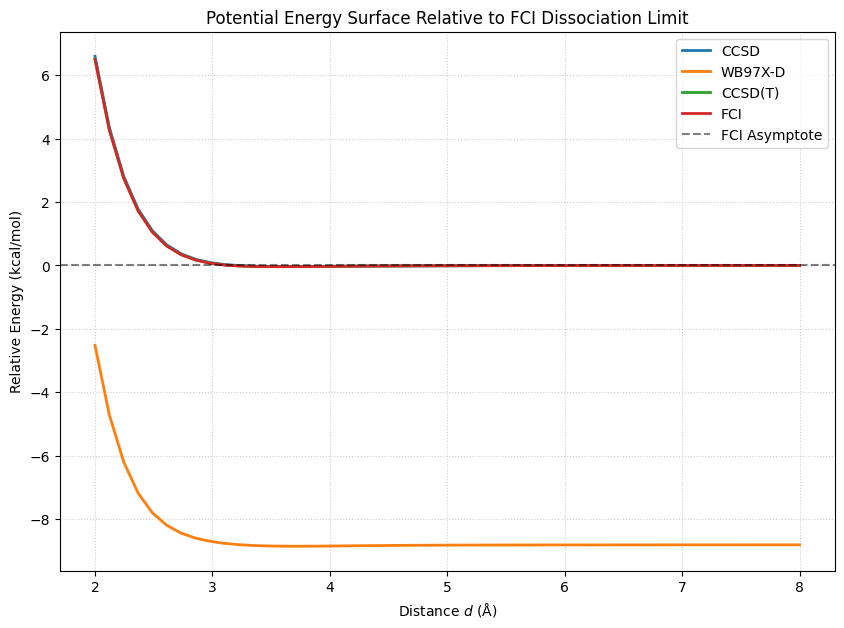

In [9]:
# 4. Shift all energies relative to E_FCI(r=8)
# We convert lists to numpy arrays to make subtraction easy
relative_energies = {}
for m in methods:
    relative_energies[m] = (np.array(energy_data[m]) - fci_asymptote) * 627.509 # Optional: Convert Hartree to kcal/mol

# 5. Plotting
plt.figure(figsize=(10, 7))

for m in methods:
    plt.plot(distances, relative_energies[m], lw=2, label=m.upper())

plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='FCI Asymptote')
plt.xlabel('Distance $d$ (Å)')
plt.ylabel('Relative Energy (kcal/mol)')
plt.title('Potential Energy Surface Relative to FCI Dissociation Limit')
#plt.ylim(-2.5, 0.25) # Adjust limits to see the "well" more clearly
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.show()

In [ ]:
for m in methods:
    #if m != 'wb97x-d':
    plt.plot(distances, energy_data[m], marker='o', label=m.upper())

plt.xlabel('Distance $d$ (Å)')
plt.ylabel('Energy (Hartree)')
plt.title('Potential Energy Surface Comparison')
plt.xlim(2.5,8)
plt.ylim(-2.3493,-2.3291)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import psi4
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup methods and range
methods = ['ccsd', 'wb97x-d', 'ccsd(t)', 'fci']
basis = 'cc-pvdz'
d_vals = np.linspace(2.0, 8.0, 50) # Scans out to 8.0 Angstroms

energy_data = {m: [] for m in methods}
distances = []

# 2. Run the scan
for d in d_vals:
    # H4 geometry configuration
    geom_string = f"""
    0 1
    H  -0.370000000  0.000000000  0.000000000
    H   0.370000000  0.000000000  0.000000000
    H  -0.370000000  0.000000000  {d}
    H   0.370000000  0.000000000  {d}
    unit angstrom
    padding 0
    symmetry c1
    """
    psi4.geometry(geom_string)
    distances.append(d)
    
    for m in methods:
        print(f"Calculating {m} at d = {d:.3f}")
        e = psi4.energy(f"{m}/{basis}")
        energy_data[m].append(e)

# 3. Define the Asymptote
# We use the last element index [-1] of the FCI list
fci_asymptote = energy_data['fci'][-1]



In [ ]:
# 4. Shift all energies relative to E_FCI(r=8)
# We convert lists to numpy arrays to make subtraction easy
relative_energies = {}
for m in methods:
    relative_energies[m] = (np.array(energy_data[m]) - fci_asymptote) * 627.509 # Optional: Convert Hartree to kcal/mol

# 5. Plotting
plt.figure(figsize=(10, 7))

for m in methods:
    plt.plot(distances, relative_energies[m], lw=2, label=m.upper())

plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='FCI Asymptote')
plt.xlabel('Distance $d$ (Å)')
plt.ylabel('Relative Energy (kcal/mol)')
plt.title('Potential Energy Surface Relative to FCI Dissociation Limit')
plt.ylim(-150, 100) # Adjust limits to see the "well" more clearly
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.show()